<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports

In [2]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Globals


In [3]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
OUTPUT_DIR = 'results/rgb_baseline'

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Setup repository



In [4]:
# Mount Google Drive to download the dataset.
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/CV_Project"

Mounted at /content/drive
RRDataset_subset.zip


In [5]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
Cloning into '/content/REPO'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 26 (delta 4), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 39.17 KiB | 4.90 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/REPO


# Install dependencies

In [6]:
# Install project dependencies.
!pip install -r requirements.txt


# Utils

In [7]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')


# Data


In [8]:
train_df = show_csv_summary(TRAIN_CSV)


File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [9]:
val_df = show_csv_summary(VAL_CSV)


File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [10]:
test_df = show_csv_summary(TEST_CSV)


File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [11]:
!file "/content/drive/MyDrive/CV_Project/RRDataset_subset.zip"

/content/drive/MyDrive/CV_Project/RRDataset_subset.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [12]:
!rm -rf /content/data/raw/RRDataset_subset
!mkdir -p /content/data/raw
!unzip -n -q "/content/drive/MyDrive/CV_Project/RRDataset_subset.zip" -d /content/data/raw

In [13]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)


Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# Train

This cell launches training for the RGB multi-task baseline.


In [14]:
!python src/train.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint_name {CHECKPOINT_NAME} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --lambda_fake {LAMBDA_FAKE} \
  --lambda_transform {LAMBDA_TRANSFORM}


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 200MB/s]

Epoch 1/10
Training: 100% 66/66 [00:44<00:00,  1.49it/s]
Validation: 100% 15/15 [00:11<00:00,  1.31it/s]
Train: {'loss': 1.3691357126690094, 'fake_acc': 0.861904761904762, 'transform_acc': 0.44666666666666666}
Val:   {'loss': 1.1591766438219282, 'fake_acc': 0.8888888888888888, 'transform_acc': 0.5666666666666667}
Val score: 0.7278
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb.pt

Epoch 2/10
Training: 100% 66/66 [00:42<00:00,  1.56it/s]
Validation: 100% 15/15 [00:11<00:00,  1.33it/s]
Train: {'loss': 0.7762200457709176, 'fake_acc': 0.9733333333333334, 'transform_acc': 0.6566666666666666}
Val:   {'loss': 0.9324817532963223, 'fake_acc': 0.9066666666666666, 'transform_acc': 0.68}
Val score: 0.7933
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb.pt

Epoch 3

# Evaluation

This cell evaluates the best checkpoint and saves:

- `predictions.csv`;
- `metrics.json`;
- `confusion_fake.png`;
- `confusion_transform.png`.


In [15]:
!python src/evaluate.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint {CHECKPOINT_PATH} \
  --output_dir {OUTPUT_DIR} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}


Using device: cuda

Evaluation results
Fake accuracy:        0.9133
Fake F1 macro:        0.9132
Transform accuracy:   0.8089
Transform F1 macro:   0.8076

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9133
  redigital: 0.9000

Saved results in:
results/rgb_baseline


# Results

In [16]:
metrics_path = Path(OUTPUT_DIR) / 'metrics.json'

if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    print(json.dumps(metrics, indent=4))
else:
    print(f'Metrics file not found: {metrics_path}')


{
    "fake_accuracy": 0.9133333333333333,
    "fake_f1_macro": 0.9132369299221357,
    "transform_accuracy": 0.8088888888888889,
    "transform_f1_macro": 0.8075680914595283,
    "fake_accuracy_by_transform": {
        "original": 0.9266666666666666,
        "transfer": 0.9133333333333333,
        "redigital": 0.9
    }
}


In [19]:
print("True fake labels:")
print(predictions_df["true_fake"].value_counts())

print("\nPredicted fake labels:")
print(predictions_df["pred_fake"].value_counts())

print("\nTrue transform labels:")
print(predictions_df["true_transform"].value_counts())

print("\nPredicted transform labels:")
print(predictions_df["pred_transform"].value_counts())

True fake labels:
true_fake
0    225
1    225
Name: count, dtype: int64

Predicted fake labels:
pred_fake
0    240
1    210
Name: count, dtype: int64

True transform labels:
true_transform
0    150
1    150
2    150
Name: count, dtype: int64

Predicted transform labels:
pred_transform
0    171
2    158
1    121
Name: count, dtype: int64


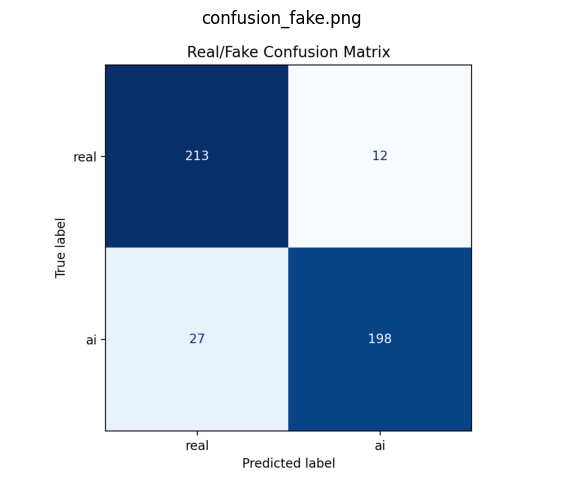

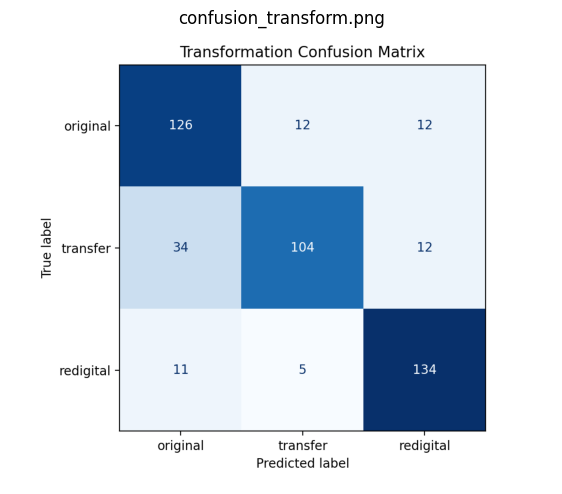

In [18]:
# Show saved confusion matrices if they exist.
for filename in ['confusion_fake.png', 'confusion_transform.png']:
    path = Path(OUTPUT_DIR) / filename
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(7, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(filename)
        plt.show()
    else:
        print(f'Missing: {path}')
